# Post-Hoc Calibration Tutorial

Post-hoc calibration adjusts a trained model's confidence to match observed accuracy. A model is calibrated if P(correct | confidence=p) = p. Most neural networks are overconfident — calibration fixes this without retraining.

**Temperature Scaling:** Divides logits by T before softmax. T>1 softens predictions. T is optimized on held-out data via NLL.

**Isotonic Regression:** Fits a non-parametric monotone mapping from model confidence to true probability, per class.

**Metric:** Expected Calibration Error (ECE) = Σ(nₖ/N)|accuracy_k - confidence_k| over bins.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import deepuq
from deepuq.metrics import expected_calibration_error

### Why Models Become Overconfident

Training too long without regularization (e.g., dropout, weight decay) causes neural networks to become overconfident. The model memorizes training data and assigns near-100% confidence even when wrong. Below we deliberately overtrain to demonstrate this effect.

## Train an Overconfident Classifier

In [2]:
from deepuq.models import MLP
from sklearn.datasets import make_blobs

# Generate 3-class data
np.random.seed(42)
X_all, y_all = make_blobs(n_samples=600, centers=3, cluster_std=1.5, random_state=42)
X_all = X_all.astype(np.float32)

# Split into train/val/test
X_train, y_train = X_all[:300], y_all[:300]
X_val, y_val = X_all[300:450], y_all[300:450]
X_test, y_test = X_all[450:], y_all[450:]

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train).long()
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val).long()
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test).long()

# Train model (overfit slightly with many epochs)
model = MLP(2, [64, 64], 3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(300):
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")
acc = (model(X_test_t).argmax(dim=1) == y_test_t).float().mean()
print(f"Test accuracy: {acc.item():.3f}")

Final training loss: 0.0029
Test accuracy: 1.000


### Reliability Diagrams and ECE

A **reliability diagram** plots predicted confidence (x-axis) vs. observed accuracy (y-axis) in bins. Perfect calibration = the diagonal. Points above the diagonal mean the model is *under*confident; points below mean *over*confident. ECE summarizes the gap as a single scalar.

## Evaluate Before Calibration

ECE before calibration: 0.0035


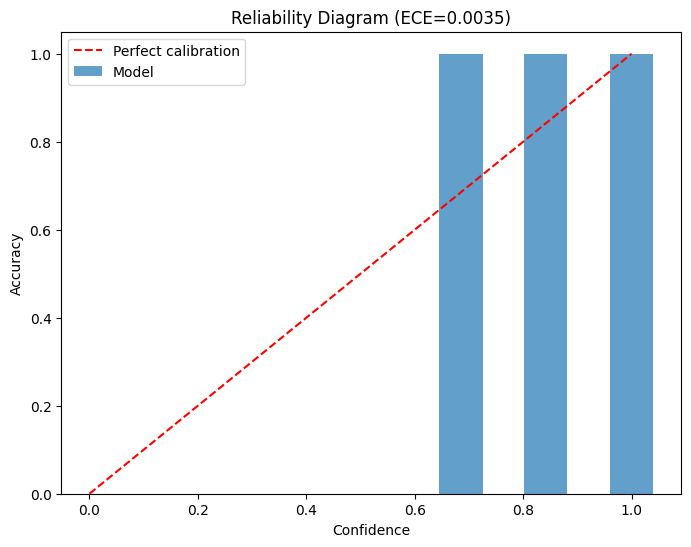

In [3]:
# Get predictions
with torch.no_grad():
    logits_test = model(X_test_t)
    probs_test = torch.softmax(logits_test, dim=1)
    confidences, predictions = probs_test.max(dim=1)

# Compute ECE - expects confidence scores and correctness labels
correctness = (predictions == y_test_t).numpy().astype(float)
ece_before = expected_calibration_error(confidences.numpy(), correctness)
print(f"ECE before calibration: {ece_before:.4f}")

# Reliability diagram
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_accs = []
bin_confs = []
bin_counts = []

for i in range(n_bins):
    mask = (confidences.numpy() > bin_boundaries[i]) & (confidences.numpy() <= bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_accs.append((predictions[mask] == y_test_t[mask]).float().mean().item())
        bin_confs.append(confidences[mask].mean().item())
        bin_counts.append(mask.sum().item())
    else:
        bin_accs.append(0)
        bin_confs.append((bin_boundaries[i] + bin_boundaries[i+1]) / 2)
        bin_counts.append(0)

plt.figure(figsize=(8, 6))
plt.bar(bin_confs, bin_accs, width=0.08, alpha=0.7, label="Model")
plt.plot([0, 1], [0, 1], 'r--', label="Perfect calibration")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE={ece_before:.4f})")
plt.legend()
plt.show()

## Temperature Scaling

In [4]:
from deepuq.methods.calibration import TemperatureScaling

# TemperatureScaling takes the model, fits on a val_loader
from torch.utils.data import DataLoader, TensorDataset
val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=len(X_val_t))

temp_scaler = TemperatureScaling(model)
temp_scaler.fit(val_loader)

# Apply to test set
calibrated_probs_temp = temp_scaler.predict_calibrated(X_test_t)
confidences_temp, predictions_temp = calibrated_probs_temp.max(dim=1)
correctness_temp = (predictions_temp == y_test_t).numpy().astype(float)
ece_temp = expected_calibration_error(confidences_temp.numpy(), correctness_temp)
print(f"Temperature: {temp_scaler.temperature.item():.3f}")
print(f"ECE after Temperature Scaling: {ece_temp:.4f}")

Temperature: 1.082
ECE after Temperature Scaling: 0.0040


## Isotonic Calibration

In [5]:
from deepuq.methods.calibration import IsotonicCalibration

# IsotonicCalibration takes model, fits on val_loader
iso_cal = IsotonicCalibration(model)
iso_cal.fit(val_loader)

# Apply to test set
calibrated_probs_iso = iso_cal.predict_calibrated(X_test_t)
confidences_iso, predictions_iso = calibrated_probs_iso.max(dim=1)
correctness_iso = (predictions_iso == y_test_t).numpy().astype(float)
ece_iso = expected_calibration_error(confidences_iso.numpy(), correctness_iso)
print(f"ECE after Isotonic Calibration: {ece_iso:.4f}")

ECE after Isotonic Calibration: 0.0028


### When to Use Each Method

- **Temperature Scaling**: Simple, single parameter, works well for most classification tasks. Preserves relative ordering of predictions.
- **Isotonic Regression**: More flexible, handles non-uniform miscalibration, but needs more validation data to avoid overfitting. Better when miscalibration is non-linear.

## Compare

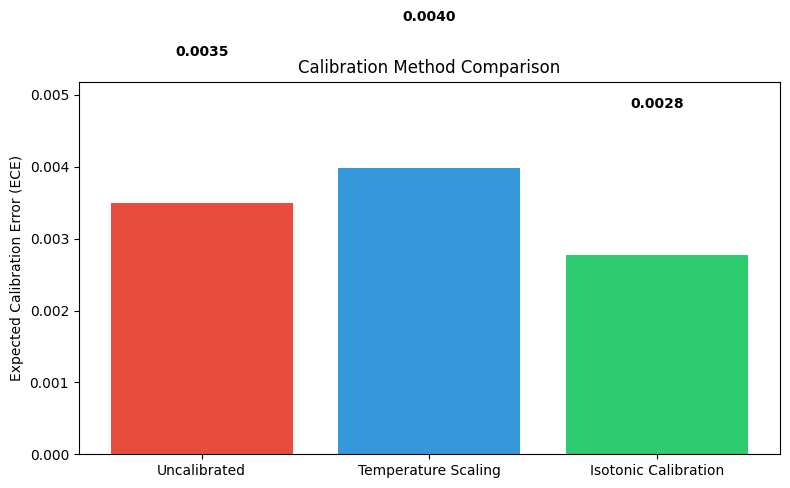

In [6]:
methods = ["Uncalibrated", "Temperature Scaling", "Isotonic Calibration"]
eces = [ece_before, ece_temp, ece_iso]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, eces, color=['#e74c3c', '#3498db', '#2ecc71'])
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Calibration Method Comparison")
for bar, ece in zip(bars, eces):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{ece:.4f}", ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(eces) * 1.3)
plt.tight_layout()
plt.show()